In [1]:
import importlib
import Hilbert3D
import Hilbert3DVisualizer

importlib.reload(Hilbert3D)
importlib.reload(Hilbert3DVisualizer)

hilbert = Hilbert3D.Hilbert3D(precision=50)
h2d = Hilbert3DVisualizer.Hilbert3DVisualizer(hilbert)

/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


# 3D Hilbertova krivka

## Test mezivypoctu pro vypocet bodu 3D krivky

In [ ]:
Q = hilbert.dec_to_octal(0.2)

print("Octal Q:", Q)



result = hilbert.ThreeD_Hilbert(Q)

print("Calculated 3D point:", result)

Octal Q: [1, 4, 6, 3, 1, 4, 6, 3, 1, 4, 6, 3, 1, 4, 6, 3, 1, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Calculated 3D point: [0.41176224 0.64706039 0.33333206]


In [ ]:
q = [2, 0, 3]

print("Q:", q)

print("ThreeD_Hilbert(q):", hilbert.ThreeD_Hilbert(q))

print("Mainstream point for n=len(q):", hilbert.calculate_mainstream_point(q, len(q)))

Q: [2, 0, 3]
ThreeD_Hilbert(q): [0.625 0.625 0.125]
Mainstream point for n=len(q): [0.5625 0.6875 0.0625]


## Hledání minima za pomoci Hoelderova algoritmu

## Pro vlastní funkci

Použitá funkce (`whatFunc = 0`):

\[
f(x,y,z) = (x-0.3)^2 + (y-0.7)^2 + (z-0.1)^2
\]

Globální minimum: $f_{\min}=0$ v bodě $(0.3, 0.7, 0.1)$.

In [ ]:
x_min1=0
x_max1=1
y_min1=0
y_max1=1
z_min1=0
z_max1=1
true_min1=0.0

In [3]:
df = h2d.holder_table_simple([2,4,6,8,10,12,14,17,18], whatFunc=1, H=-2, I=1, r=1.0487567501205, eps=1e-8, max_iter=1500, ftol=1e-8, true_min=0.0, true_point=(0.5, 0.5, 0.5))

/home/eliska/UCIME_SE_PYTHON/Hilbert3D.py:371: RuntimeWarning: divide by zero encountered in scalar power
  y = 0.5 * (xk[i - 1] + xk[i]) - (zk[i] - zk[i - 1]) / (2 * r * h_i * (xk[i] - xk[i - 1]) ** ((1 - N) / N))


Holder algorithm stopped after 343 iterations - ftol condition satisfied.
Holder algorithm stopped after 1004 iterations - ftol condition satisfied.
 n       f_diff      y_x      y_y      y_z  distance  holder_iterations
 2 1.545320e-08 0.500000 0.500009 0.500000  0.000009               1500
 4 1.702346e-06 0.500000 0.500000 0.500130  0.000130               1500
 6 2.441406e-02 0.484375 0.515625 0.500000  0.022097               1500
 8 1.525879e-03 0.496094 0.503906 0.500000  0.005524               1500
10 9.536743e-05 0.499023 0.500977 0.500000  0.001381               1500
12 5.960464e-06 0.500000 0.499756 0.500244  0.000345               1500
14 6.332994e-06 0.499878 0.500000 0.500305  0.000329               1500
17 6.548362e-09 0.499992 0.500010 0.500000  0.000012                343
18 7.639755e-09 0.499996 0.500011 0.499990  0.000015               1004


In [ ]:
results, df = h2d.compare_iterations_by_curve_order(
    n_values=[6,7,8,9,10,11,12,13,14,15,16,17,18],
    x_min=x_min1, x_max=x_max1,
    y_min=y_min1, y_max=y_max1,
    whatFunc=0,  
    true_min=true_min1,
    ftol=1e-5,
    r=1.055346212,
    H=-2
   
)

Brute maxiter reached: 1000 function evaluations, f_min = 0.004693282320571961
Differential evolution stopped after 15 generations - ftol condition satisfied.
Differential evolution completed: 15 generations, 732 function evaluations, f_min = 7.105271276866534e-17
Brute maxiter reached: 1000 function evaluations, f_min = 0.00428731089600197
Differential evolution stopped after 12 generations - ftol condition satisfied.
Differential evolution completed: 12 generations, 597 function evaluations, f_min = 7.295135301486935e-17
Brute maxiter reached: 1000 function evaluations, f_min = 0.004207847660523874
Differential evolution stopped after 13 generations - ftol condition satisfied.
Differential evolution completed: 13 generations, 642 function evaluations, f_min = 1.885918414297535e-12
Holder algorithm stopped after 313 iterations - ftol condition satisfied.
Brute maxiter reached: 1000 function evaluations, f_min = 0.004423920387190856
Differential evolution stopped after 11 generations -

Holder algorithm stopped after 829 iterations - smallest interval below threshold.
Holder algorithm stopped after 939 iterations - smallest interval below threshold.
Holder algorithm stopped after 594 iterations - smallest interval below threshold.
Holder algorithm stopped after 603 iterations - smallest interval below threshold.
Holder algorithm stopped after 499 iterations - smallest interval below threshold.
Holder algorithm stopped after 485 iterations - smallest interval below threshold.
Holder algorithm stopped after 285 iterations - smallest interval below threshold.
Holder algorithm stopped after 323 iterations - smallest interval below threshold.
Holder algorithm stopped after 393 iterations - smallest interval below threshold.
Holder algorithm stopped after 427 iterations - smallest interval below threshold.
Holder algorithm stopped after 327 iterations - smallest interval below threshold.
Holder algorithm stopped after 306 iterations - smallest interval below threshold.
Hold

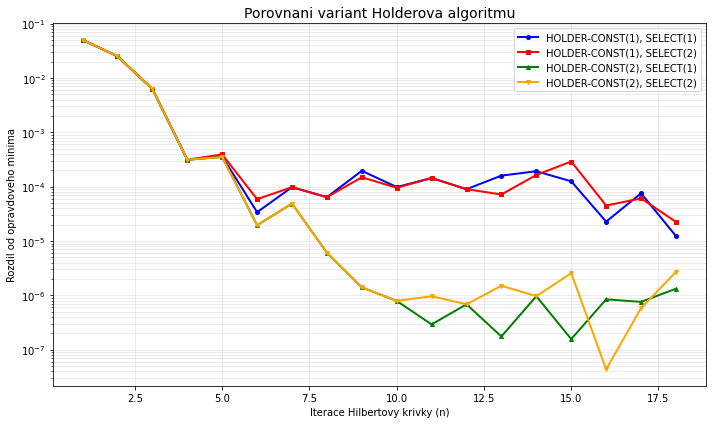

In [ ]:
h2d.compare_holder_variants(r=1.055346212, eps=1e-3, max_iter=1500, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=0, true_min=true_min1)

Holder algorithm stopped after 829 iterations - smallest interval below threshold.
Holder algorithm stopped after 939 iterations - smallest interval below threshold.
Holder algorithm stopped after 594 iterations - smallest interval below threshold.
Holder algorithm stopped after 603 iterations - smallest interval below threshold.
Holder algorithm stopped after 499 iterations - smallest interval below threshold.
Holder algorithm stopped after 485 iterations - smallest interval below threshold.
Holder algorithm stopped after 285 iterations - smallest interval below threshold.
Holder algorithm stopped after 323 iterations - smallest interval below threshold.
Holder algorithm stopped after 393 iterations - smallest interval below threshold.
Holder algorithm stopped after 427 iterations - smallest interval below threshold.
Holder algorithm stopped after 327 iterations - smallest interval below threshold.
Holder algorithm stopped after 306 iterations - smallest interval below threshold.
Hold

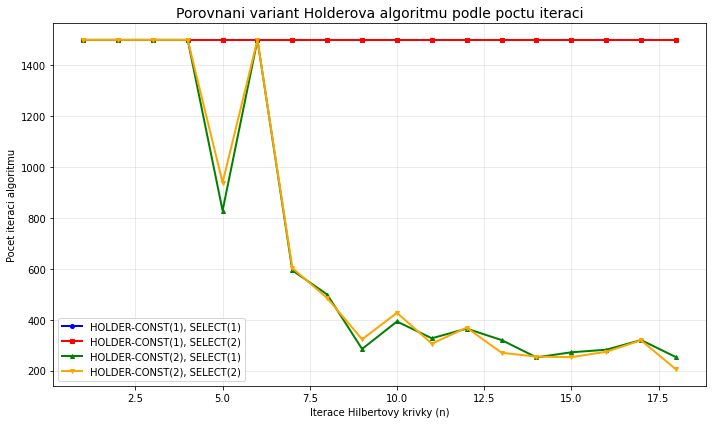

In [ ]:
h2d.compare_holder_variants_iterations(
    r=1.055346212,
    eps=1e-3,
    max_iter=1500,
    N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
    whatFunc=0,
    true_min=true_min1
)

Holder algorithm stopped after 391 iterations - smallest interval below threshold.
Holder algorithm stopped after 249 iterations - smallest interval below threshold.
Holder algorithm stopped after 329 iterations - smallest interval below threshold.


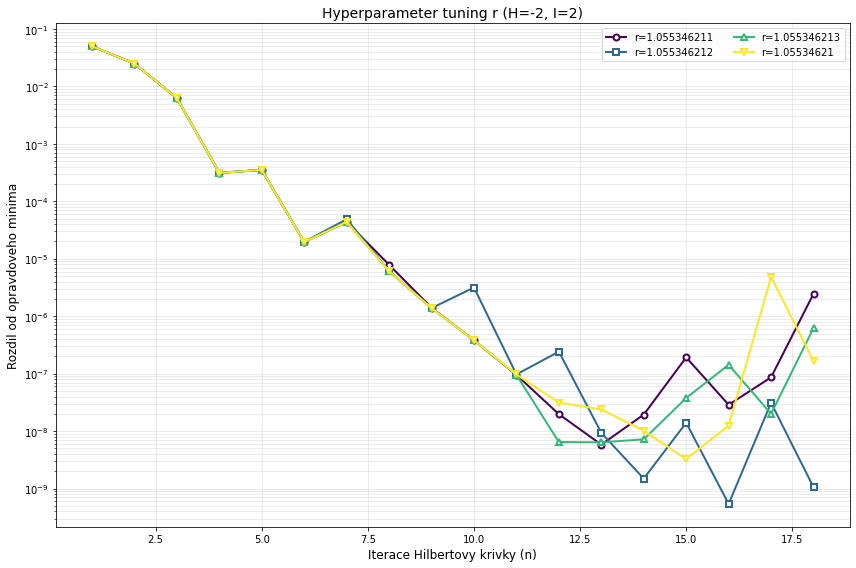

In [ ]:
h2d.hyperparameter_tuning_r(r_values=[1.055346211,1.055346212,1.055346213,1.05534621], H=-2, I=2, eps=0.00001, max_iter=400, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=0, true_min=true_min1)

## Pro Schwefelovu funkci 1.2 (škálovanou do [0,1]^3)

Použitá funkce (`whatFunc = 1`):

\[
f_1(u,v,w) = u^2 + (u+v)^2 + (u+v+w)^2
\]

kde

\[
\begin{aligned}
u &= -5 + 10x, \\
v &= -5 + 10y, \\
w &= -5 + 10z.
\end{aligned}
\]

Tedy máme $f_1(u,v,w)$ pro $x,y,z \in [0,1]$.

Globální minimum: $f_{\min}=0$ v bodě $(x,y,z)=(0.5,0.5,0.5)$.

In [ ]:
x_min2=-5
x_max2=5
y_min2=-5
y_max2=5
z_min2=-5
z_max2=5

true_min2=0.0

Holder algorithm stopped after 606 iterations - smallest interval below threshold.
Holder algorithm stopped after 287 iterations - smallest interval below threshold.
Holder algorithm stopped after 1036 iterations - smallest interval below threshold.
Holder algorithm stopped after 1058 iterations - smallest interval below threshold.
Holder algorithm stopped after 418 iterations - smallest interval below threshold.
Holder algorithm stopped after 295 iterations - smallest interval below threshold.
Holder algorithm stopped after 464 iterations - smallest interval below threshold.
Holder algorithm stopped after 452 iterations - smallest interval below threshold.
Holder algorithm stopped after 274 iterations - smallest interval below threshold.
Holder algorithm stopped after 177 iterations - smallest interval below threshold.
Holder algorithm stopped after 325 iterations - smallest interval below threshold.
Holder algorithm stopped after 314 iterations - smallest interval below threshold.
Ho

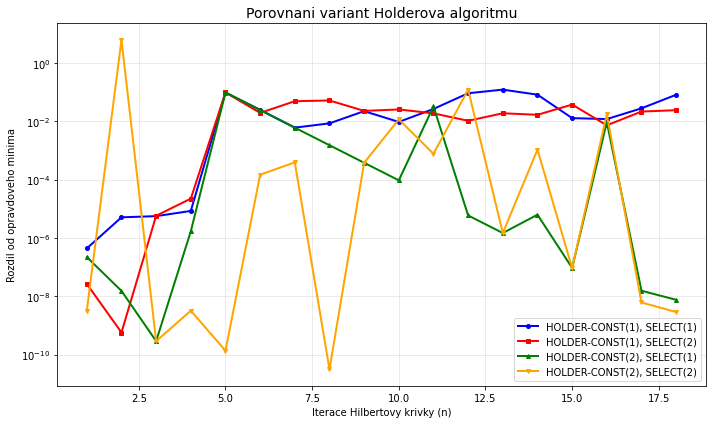

In [7]:
h2d.compare_holder_variants(r=1.0487567501205, eps=1e-5, max_iter=1500, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=1, true_min=true_min2)

Holder algorithm stopped after 606 iterations - smallest interval below threshold.
Holder algorithm stopped after 287 iterations - smallest interval below threshold.
Holder algorithm stopped after 1036 iterations - smallest interval below threshold.
Holder algorithm stopped after 1058 iterations - smallest interval below threshold.
Holder algorithm stopped after 418 iterations - smallest interval below threshold.
Holder algorithm stopped after 295 iterations - smallest interval below threshold.
Holder algorithm stopped after 464 iterations - smallest interval below threshold.
Holder algorithm stopped after 452 iterations - smallest interval below threshold.
Holder algorithm stopped after 274 iterations - smallest interval below threshold.
Holder algorithm stopped after 177 iterations - smallest interval below threshold.
Holder algorithm stopped after 325 iterations - smallest interval below threshold.
Holder algorithm stopped after 314 iterations - smallest interval below threshold.
Ho

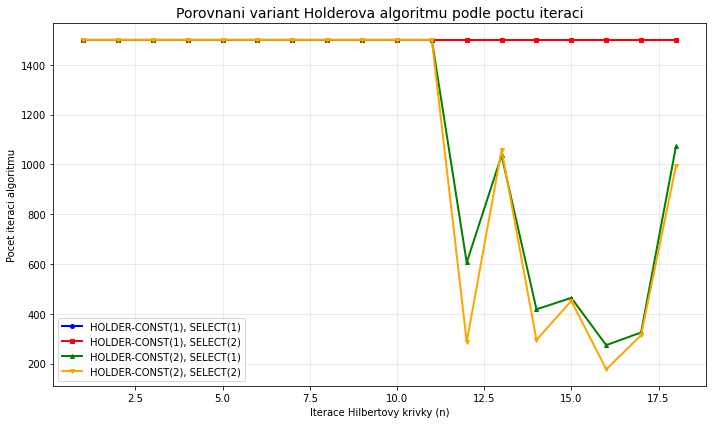

In [8]:
h2d.compare_holder_variants_iterations(
    r=1.0487567501205,
    eps=1e-5,
    max_iter=1500,
    N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
    whatFunc=1,
    true_min=true_min2
)

In [ ]:
results, df = h2d.compare_iterations_by_curve_order(
    n_values=[8,9,10,11,12,13,15,16,17,18],
    x_min=x_min2, x_max=x_max2,
    y_min=y_min2, y_max=y_max2,
    whatFunc=1,  
    true_min=true_min2,
    ftol=1e-4,
    r=1.0487567501205,
    H=-2,
    max_iter_holder=1500,
    I=1
)

Brute maxiter reached: 1000 function evaluations, f_min = 0.6307331087373651
Differential evolution stopped after 26 generations - ftol condition satisfied.
Differential evolution completed: 26 generations, 1247 function evaluations, f_min = 8.320826237526534e-15
Brute maxiter reached: 1000 function evaluations, f_min = 0.6006202412588963
Differential evolution stopped after 22 generations - ftol condition satisfied.
Differential evolution completed: 22 generations, 1063 function evaluations, f_min = 3.052237779699674e-14
Brute maxiter reached: 1000 function evaluations, f_min = 0.5938473241749469
Differential evolution stopped after 20 generations - ftol condition satisfied.
Differential evolution completed: 20 generations, 969 function evaluations, f_min = 4.153506230729198e-10
Holder algorithm stopped after 312 iterations - ftol condition satisfied.
Brute maxiter reached: 1000 function evaluations, f_min = 0.5934939255277121
Differential evolution stopped after 23 generations - ftol

/home/eliska/UCIME_SE_PYTHON/Hilbert3D.py:371: RuntimeWarning: divide by zero encountered in scalar power
  y = 0.5 * (xk[i - 1] + xk[i]) - (zk[i] - zk[i - 1]) / (2 * r * h_i * (xk[i] - xk[i - 1]) ** ((1 - N) / N))


Brute maxiter reached: 1000 function evaluations, f_min = 0.5993154023599345
Differential evolution stopped after 17 generations - ftol condition satisfied.
Differential evolution completed: 17 generations, 842 function evaluations, f_min = 1.7602354359374162e-13
Holder algorithm stopped after 235 iterations - ftol condition satisfied.
Brute maxiter reached: 1000 function evaluations, f_min = 0.7309211898245849
Differential evolution stopped after 22 generations - ftol condition satisfied.
Differential evolution completed: 22 generations, 1067 function evaluations, f_min = 7.500145045633532e-15
Holder algorithm stopped after 584 iterations - ftol condition satisfied.

SOUHRNNA TABULKA - POCET ITERACI PRO RUZNE RADY KRIVKY

 n  Brute  Diff. Evolution  Holder
 8   1000             1247    1500
 9   1000             1063    1500
10   1000              969     312
11   1000             1108    1500
12   1000             1243     211
13   1000             1018     369
15   1000             

Holder algorithm stopped after 410 iterations - smallest interval below threshold.
Holder algorithm stopped after 633 iterations - smallest interval below threshold.
Holder algorithm stopped after 606 iterations - smallest interval below threshold.
Holder algorithm stopped after 532 iterations - smallest interval below threshold.
Holder algorithm stopped after 472 iterations - smallest interval below threshold.
Holder algorithm stopped after 312 iterations - smallest interval below threshold.
Holder algorithm stopped after 697 iterations - smallest interval below threshold.
Holder algorithm stopped after 476 iterations - smallest interval below threshold.
Holder algorithm stopped after 546 iterations - smallest interval below threshold.
Holder algorithm stopped after 418 iterations - smallest interval below threshold.
Holder algorithm stopped after 317 iterations - smallest interval below threshold.
Holder algorithm stopped after 383 iterations - smallest interval below threshold.
Hold

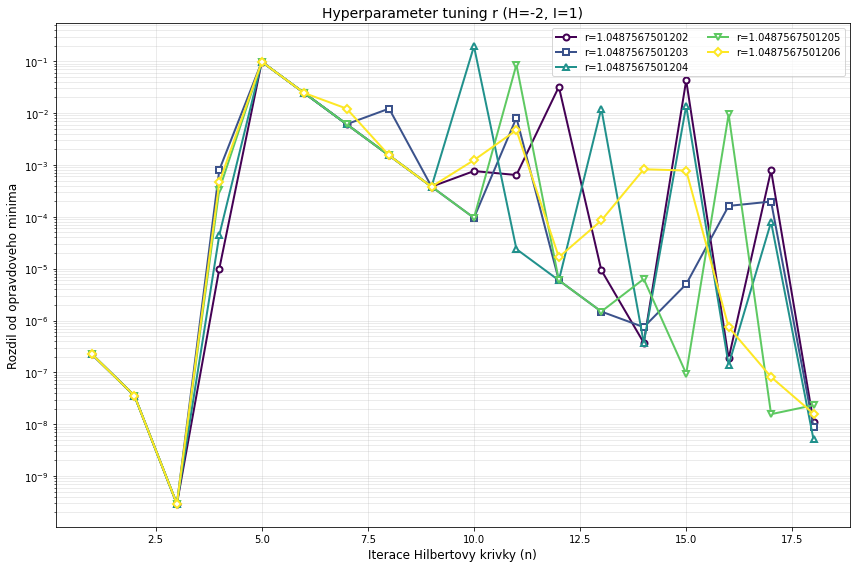

In [ ]:
h2d.hyperparameter_tuning_r(r_values=[1.0487567501202,
1.0487567501203,
1.0487567501204,
1.0487567501205,
1.0487567501206],H=-2, I=1, eps=1e-5, max_iter=1000, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=1, true_min=true_min2)

## Pro funkci s absolutními hodnotami

Použitá funkce (`whatFunc = 2`):

\[
f_2(x,y,z) = |x-0.1| + |y-0.55| + |z-0.55|
\]

Globální minimum: $f_{\min}=0$ v bodě $(0.1,0.55,0.55)$.

In [ ]:
x_min3=0
x_max3=1
y_min3=0
y_max3=1
z_min3=0
z_max3=1
true_min3 = 0.0

Holder algorithm stopped after 847 iterations - smallest interval below threshold.
Holder algorithm stopped after 601 iterations - smallest interval below threshold.
Holder algorithm stopped after 299 iterations - smallest interval below threshold.
Holder algorithm stopped after 247 iterations - smallest interval below threshold.
Holder algorithm stopped after 406 iterations - smallest interval below threshold.
Holder algorithm stopped after 135 iterations - smallest interval below threshold.
Holder algorithm stopped after 156 iterations - smallest interval below threshold.
Holder algorithm stopped after 152 iterations - smallest interval below threshold.
Holder algorithm stopped after 175 iterations - smallest interval below threshold.
Holder algorithm stopped after 236 iterations - smallest interval below threshold.
Holder algorithm stopped after 136 iterations - smallest interval below threshold.
Holder algorithm stopped after 121 iterations - smallest interval below threshold.
Hold

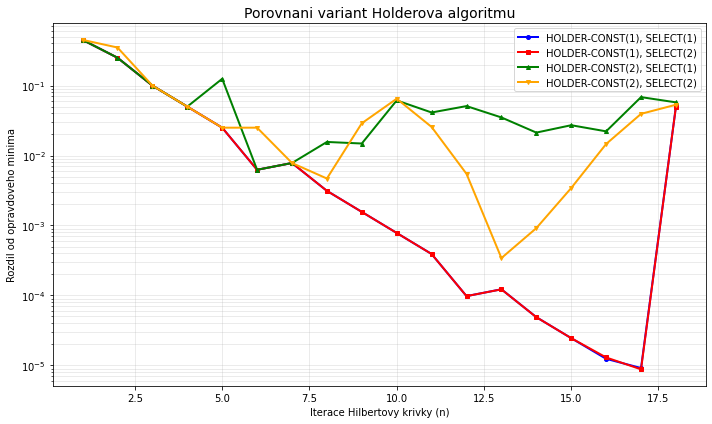

In [14]:
h2d.compare_holder_variants(r=1.0487567501201, eps=1e-5, max_iter=1500, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=2, true_min=true_min3)

Holder algorithm stopped after 745 iterations - smallest interval below threshold.
Holder algorithm stopped after 773 iterations - smallest interval below threshold.
Holder algorithm stopped after 265 iterations - smallest interval below threshold.
Holder algorithm stopped after 220 iterations - smallest interval below threshold.
Holder algorithm stopped after 307 iterations - smallest interval below threshold.
Holder algorithm stopped after 162 iterations - smallest interval below threshold.
Holder algorithm stopped after 337 iterations - smallest interval below threshold.
Holder algorithm stopped after 159 iterations - smallest interval below threshold.
Holder algorithm stopped after 221 iterations - smallest interval below threshold.
Holder algorithm stopped after 152 iterations - smallest interval below threshold.
Holder algorithm stopped after 241 iterations - smallest interval below threshold.
Holder algorithm stopped after 212 iterations - smallest interval below threshold.
Hold

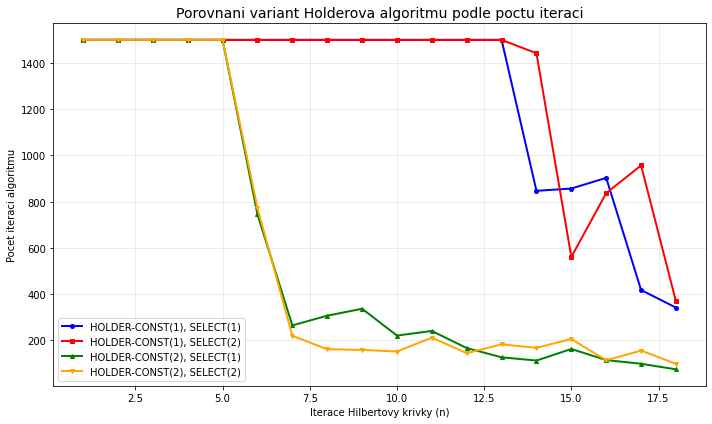

In [12]:
h2d.compare_holder_variants_iterations(
    r=1.0487567501205,
    eps=1e-5,
    max_iter=1500,
    N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18],
    whatFunc=2,
    true_min=true_min3
)

In [16]:
results, df = h2d.compare_iterations_by_curve_order(
    n_values=[8,9,10,11,12,13,14,15,16,17,18],
    x_min=x_min3, x_max=x_max3,
    y_min=y_min3, y_max=y_max3,
    whatFunc=2,  
    true_min=true_min3,
    ftol=1e-4,
    r=1.12,
    H=-1,
    I=1
)

Brute maxiter reached: 1000 function evaluations, f_min = 0.1178444069082615
Differential evolution stopped after 29 generations - ftol condition satisfied.
Differential evolution completed: 29 generations, 1610 function evaluations, f_min = 1.383240658126006e-08
Brute maxiter reached: 1000 function evaluations, f_min = 0.11846612236695356
Differential evolution stopped after 28 generations - ftol condition satisfied.
Differential evolution completed: 28 generations, 1457 function evaluations, f_min = 7.093907865296512e-08
Brute maxiter reached: 1000 function evaluations, f_min = 0.12034886446781448
Differential evolution stopped after 28 generations - ftol condition satisfied.
Differential evolution completed: 28 generations, 1565 function evaluations, f_min = 4.73862625887389e-05
Brute maxiter reached: 1000 function evaluations, f_min = 0.12104389537125818
Differential evolution stopped after 27 generations - ftol condition satisfied.
Differential evolution completed: 27 generations,

/home/eliska/UCIME_SE_PYTHON/Hilbert3D.py:363: RuntimeWarning: divide by zero encountered in scalar power
  y = 0.5 * (xk[i - 1] + xk[i]) - (zk[i] - zk[i - 1]) / (2 * r * h_i * (xk[i] - xk[i - 1]) ** ((1 - N) / N))


Holder algorithm stopped after 916 iterations - smallest interval below threshold.
Holder algorithm stopped after 905 iterations - smallest interval below threshold.
Holder algorithm stopped after 847 iterations - smallest interval below threshold.
Holder algorithm stopped after 576 iterations - smallest interval below threshold.
Holder algorithm stopped after 992 iterations - smallest interval below threshold.
Holder algorithm stopped after 534 iterations - smallest interval below threshold.
Holder algorithm stopped after 857 iterations - smallest interval below threshold.
Holder algorithm stopped after 976 iterations - smallest interval below threshold.
Holder algorithm stopped after 796 iterations - smallest interval below threshold.
Holder algorithm stopped after 742 iterations - smallest interval below threshold.
Holder algorithm stopped after 678 iterations - smallest interval below threshold.
Holder algorithm stopped after 903 iterations - smallest interval below threshold.
Hold

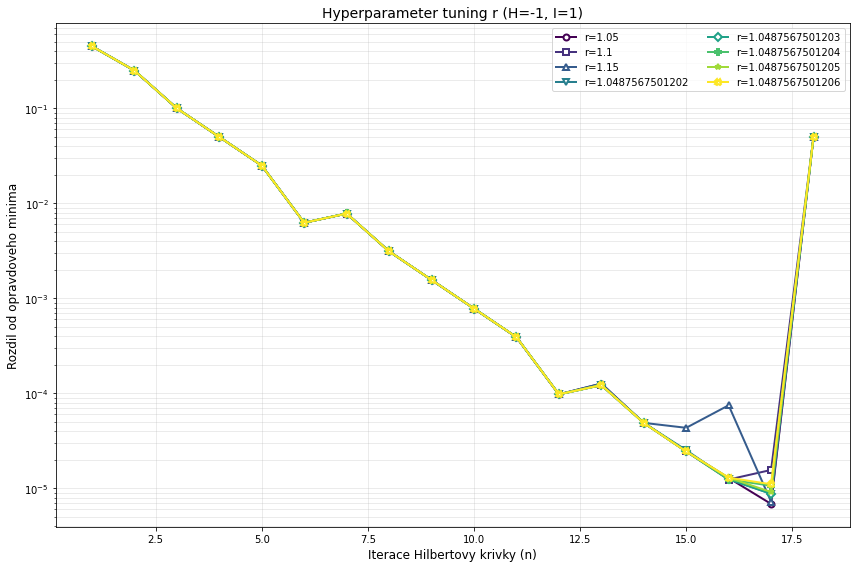

In [9]:
h2d.hyperparameter_tuning_r(r_values=[1.05, 1.1, 1.15, 1.0487567501202,
1.0487567501203,
1.0487567501204,
1.0487567501205,
1.0487567501206],H=-1,I=2,eps=1e-5,max_iter=1000, N_vals=[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18], whatFunc=2, true_min=true_min3)

## Vykresleni grafu 3D Hilbertovy krivky

In [4]:
h2d.plot_hilbert_polygon(3)
h2d.plot_mainstream_hilbert(2)
h2d.plot_mainstream_hilbert_cubes(1)